# Orbit-to-ground with **DIRFM** — a TLE-propagated WorldView-2 pass

`tutorial_dirfm_basics.ipynb` built every DIRFM concept around an airborne/terrestrial
sensor sitting a few hundred metres above a small scene. This notebook moves the sensor
**into orbit**: we take the current two-line element set (TLE) for the WorldView-2 satellite
(NORAD 35946) from Celestrak, propagate it ourselves with SGP4, pick an upcoming near-overhead
daylight pass, and use that trajectory to drive a sensor that images the ground.

**Why TLEs.** protoDIRSIG's use case is driving DIRSIG *procedurally from catalog orbital
data*, and a TLE is that catalog's native format — every tracked object has one, refreshed
daily. DIRSIG's bundled **`StkImport1`** demo (the only orbit-to-ground demo it ships) instead
reads an STK-exported ephemeris/attitude pair for one 2012 pass. That demo is still the
reference for the *shape* of the problem — a real LEO orbit driving a nadir-pointing
imager — but its `.e`/`.a` files are not a data source here, and this notebook does not read
them.

| Stage | What it does |
|---|---|
| 0 | Environment, capability check (EarthGrid? orientation engines? an SGP4/TLE propagator?) |
| 1 | Fetch the TLE, choose a pass, propagate with SGP4, convert TEME → ECEF, sanity-check the orbit independently of DIRSIG, build the FlexMotion pair |
| 2 | Substitute ground scene at the pass target + sensor + `TASKS` for the pass window |
| 3 | Render, display, compare against the original `StkImport1` |

---
# Stage 0 — Orientation and capability check

## Environment setup

Same convention as `tutorial_dirfm_basics.ipynb`: the DIRSIG install is read from
**`DIRSIG_HOME`** if set, otherwise this machine's install
(`~/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64`) is used as the documented fallback. The
kernel does not inherit your shell's `PATH`, so we prepend `$DIRSIG_HOME/bin` explicitly and
assert that `scene2hdf` and `dirsig5` resolve.

In [1]:
import os
import shutil
from pathlib import Path

# DIRSIG_HOME from the environment if set; otherwise this machine's documented default.
DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()

os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)          # re-export so DIRSIG sees it too
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")

print("DIRSIG_HOME =", DIRSIG_HOME)
print("scene2hdf ->", shutil.which("scene2hdf"))
print("dirsig5   ->", shutil.which("dirsig5"))
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), \
    "DIRSIG binaries not on PATH — set DIRSIG_HOME to your DIRSIG install."

DIRSIG_HOME = /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
scene2hdf -> /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64/bin/scene2hdf
dirsig5   -> /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64/bin/dirsig5


## Project paths

Render inputs/outputs for this notebook go to `outputs/orbit_to_ground_input` and
`outputs/orbit_to_ground_output`. Downloaded orbital data — the TLE and the JPL planetary
ephemeris used to compute Sun elevation — is cached in `outputs/_orbit_data/`, which is
covered by the `outputs/` gitignore pattern like every other run artifact.

In [2]:
PROJECT = Path.cwd()
if PROJECT.name == "notebooks":       # notebook lives in protoDIRSIG/notebooks/
    PROJECT = PROJECT.parent
OUTPUTS = PROJECT / "outputs"
IN_DIR, OUT_DIR = OUTPUTS / "orbit_to_ground_input", OUTPUTS / "orbit_to_ground_output"
DATA_DIR = OUTPUTS / "_orbit_data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

DIRFM_REPO = Path("/home/kevin-kearney/dev/dirsig-file-maker")   # read-only; edit if yours differs
print("project :", PROJECT)
print("data    :", DATA_DIR)

project : /home/kevin-kearney/dev/protoDIRSIG
data    : /home/kevin-kearney/dev/protoDIRSIG/outputs/_orbit_data


## Capability check — answered from the dirfm source

We don't take any answer on faith; the cell below reads the checked-out dirfm source
directly (and first confirms the imported `dirfm` *is* that checkout, not some other copy).

**Q1 — does dirfm expose DIRSIG's `EarthGrid` plugin?** `StkImport1` gets its Earth from
`EarthGrid` draped with Blue Marble imagery. We search every `.py` file for `EarthGrid`. The
string `grid` alone *does* appear, but only in `dirfm/utilities/` helpers (a DGGRID wrapper, a
curved-tile generator, a grid position generator) — none is a DIRSIG plugin.

**Q2 — what can FlexMotion express for an orbiting platform?** (a) does
`WaypointsLocationEngine` take plain numeric `(t, x, y, z)` samples and let us choose the
frame; (b) which orientation engines exist — in particular any quaternion engine; (c) what
`LookAtOrientationEngine` writes for its `up` vector. DIRSIG's own nadir idiom (`StkImport1`'s
`stare.motion`) uses `<up type="velocity" frame="ecef">`.

**Q3 — does dirfm wrap an SGP4/TLE propagator?** The quick check
`grep -rni "sgp4|tle" dirfm/*.py demos/*.py` is *not* a clean test: a case-insensitive
substring `tle` matches `ti`**`tle`**, `li`**`ttle`**`-endian` and `uni`**`tle`**`ss`, so it does
return hits.
We print those substring hits to show they are all false positives, then run the real test: a
whole-word search of the package **and** its `demos/` for `sgp4`, `tle`, `teme`, `two-line`,
`norad`, `celestrak`, `skyfield`, plus any import of an SGP4 library.

In [3]:
import inspect
import re
import dirfm
from dirfm import flexible_motion as fm

PKG = Path(dirfm.__file__).parent
assert PKG.resolve().is_relative_to(DIRFM_REPO.resolve()), f"imported dirfm is {PKG}, not the {DIRFM_REPO} checkout"

sources = {p.relative_to(DIRFM_REPO): p.read_text()
           for root in (PKG, DIRFM_REPO / "demos") for p in root.rglob("*.py")}

def files_matching(pattern, flags=re.IGNORECASE):
    rx = re.compile(pattern, flags)
    return sorted(str(k) for k, s in sources.items() if rx.search(s))

print(f"searched {len(sources)} .py files under {PKG.name}/ and demos/\n")

print("Q1  'EarthGrid'                      :", files_matching("EarthGrid") or "NONE")
print("    'grid' (any case, substring)     :", files_matching("grid"))
print()

print("Q2a WaypointsLocationEngine.__init__ :", inspect.signature(fm.WaypointsLocationEngine.__init__))
print("    add_point                        :", inspect.signature(fm.WaypointsLocationEngine.add_point))
wp_src = inspect.getsource(fm.WaypointsLocationEngine.write)
print("    write() attributes               :",
      [ln.strip() for ln in wp_src.splitlines() if re.search(r"source=|datetime=|frame=", ln)])
ori = sorted(n for n, c in vars(fm).items()
             if inspect.isclass(c) and issubclass(c, fm.OrientationEngine) and c is not fm.OrientationEngine)
print("Q2b orientation engines              :", ori)
print("    'quaternion' anywhere            :", files_matching("quaternion") or "NONE")
up_src = [ln.strip() for ln in inspect.getsource(fm.LookAtOrientationEngine).splitlines() if '"up"' in ln]
print("Q2c LookAt writes up as              :", up_src)
print()

substring = [(str(k), m.group(0), s[max(0, m.start() - 12): m.end() + 8].replace("\n", " "))
             for k, s in sources.items() if str(k).count("/") <= 1
             for m in re.finditer("sgp4|tle", s, re.IGNORECASE)]
print(f"Q3  naive substring 'sgp4|tle'       : {len(substring)} hits, e.g.")
for f, hit, ctx in substring[:4]:
    print(f"      {f:28s} …{ctx}…")
WORDS = r"\b(sgp4|sdp4|tle|tles|teme|two[-_ ]?line|norad|celestrak|skyfield)\b"
print("    whole-word propagator terms      :", files_matching(WORDS) or "NONE")
print("    imports of an SGP4 library       :",
      files_matching(r"^\s*(import|from)\s+(sgp4|skyfield|orekit|poliastro)", re.MULTILINE) or "NONE")

assert not files_matching("EarthGrid")
assert not files_matching("quaternion")
assert not files_matching(WORDS)

searched 79 .py files under dirfm/ and demos/

Q1  'EarthGrid'                      : NONE
    'grid' (any case, substring)     : ['dirfm/emissivity.py', 'dirfm/utilities/brdf_viewer.py', 'dirfm/utilities/curved_tile_generator.py', 'dirfm/utilities/dggrid.py', 'dirfm/utilities/grid_position_generator.py', 'dirfm/utilities/sqt_tool.py']

Q2a WaypointsLocationEngine.__init__ : (self, frame='scene')
    add_point                        : (self, time, position)
    write() attributes               : ['source="internal",', 'datetime="relative",', 'frame=self._frame,']
Q2b orientation engines              : ['EulerOrientationEngine', 'LookAtOrientationEngine', 'SpinOrientationEngine', 'VelocityOrientationEngine']
    'quaternion' anywhere            : NONE
Q2c LookAt writes up as              : ['et.SubElement(orient, "up", frame="scene", vector=self._up)']

Q3  naive substring 'sgp4|tle'       : 4 hits, e.g.
      dirfm/materials.py           …       # Little-endian …
      dirfm/platform_s

    whole-word propagator terms      : NONE


    imports of an SGP4 library       : NONE


### Findings

* **No `EarthGrid`.** dirfm has no wrapper for the plugin that supplies `StkImport1`'s Earth.
  Stage 2 substitutes a conventional `SCENE` with a `GroundPlane` — a deliberate stand-in for
  a plugin dirfm doesn't expose, **not** a reproduction of the Blue Marble globe.
* **Waypoints are plain numbers in a frame we choose.** `WaypointsLocationEngine(frame=...)`
  takes `add_point(time, position)` and writes `source="internal"` / `datetime="relative"` with
  our `frame` attribute. That is all an orbit needs: `(t, x, y, z)` in `frame="ecef"`. It is
  also the whole interface — dirfm neither knows nor checks what frame the numbers are *really*
  in.
* **No quaternion engine, and LookAt's `up` is a fixed vector.** The engines are `Euler`,
  `LookAt`, `Spin` and `Velocity`, and `LookAtOrientationEngine` always writes
  `<up frame="scene" vector="…"/>` — there is no way to express `stare.motion`'s
  `<up type="velocity">`. Stage 1 works around this with a fixed vector and checks that it is
  sound for this pass.
* **No SGP4/TLE propagator.** The naive `grep` hits are all substrings of `title`,
  `little-endian` and `unitless`; the whole-word search and the import search both come back empty. So TLE
  propagation happens in plain Python (Stage 1, using `skyfield`) and only its *output* —
  ECEF samples — crosses into dirfm. Everything downstream of "get me ECEF positions" is the
  existing `WaypointsLocationEngine(frame="ecef")` mechanism.

---
# Stage 1 — Trajectory from a TLE

## Fetch and validate the TLE

A TLE is two 69-character lines (plus an optional name line) of *mean* orbital elements, fit
by the tracking network and meant to be propagated with the **SGP4** model — only SGP4
reproduces the orbit the elements were fit to. We fetch WorldView-2's current set from
Celestrak's GP API by catalog number.

The catalog number 35946 originally came from the `StkImport1` filename
(`WORLDVIEW-2_35946.e`). We don't trust the filename: the cell checks that the record Celestrak
returns for 35946 is actually named WorldView-2, that its international designator is
**2009-055A** (WorldView-2 launched 8 October 2009), and that both lines' mod-10 checksums
are valid.

**Caching.** The TLE is written to `outputs/_orbit_data/` on first fetch and reused after
that, so re-running the notebook gives the same pass (and respects Celestrak's request not
to re-download unchanged data repeatedly). Set `REFRESH_TLE = True` to pull a new set; the
pass chosen below will then move to track the new epoch.

In [4]:
import urllib.request
from datetime import datetime, timezone

NORAD_ID = 35946
TLE_URL = f"https://celestrak.org/NORAD/elements/gp.php?CATNR={NORAD_ID}&FORMAT=tle"
TLE_FILE = DATA_DIR / f"tle_{NORAD_ID}.txt"
REFRESH_TLE = False

if REFRESH_TLE or not TLE_FILE.exists():
    with urllib.request.urlopen(TLE_URL, timeout=30) as r:
        text = r.read().decode()
    fetched = datetime.now(timezone.utc).isoformat(timespec="seconds")
    TLE_FILE.write_text(f"# fetched {fetched} from {TLE_URL}\n{text.strip()}\n")

def tle_checksum_ok(line):
    """TLE mod-10 checksum: digits count face value, '-' counts 1, everything else 0."""
    s = sum(int(c) if c.isdigit() else (1 if c == "-" else 0) for c in line[:68])
    return s % 10 == int(line[68])

comment, name, line1, line2 = [ln.rstrip() for ln in TLE_FILE.read_text().splitlines()]
print(comment)
print(name, line1, line2, sep="\n")

assert line1.startswith("1 ") and line2.startswith("2 ") and len(line1) == len(line2) == 69
assert tle_checksum_ok(line1) and tle_checksum_ok(line2), "TLE checksum failure"
assert int(line1[2:7]) == int(line2[2:7]) == NORAD_ID
assert "WORLDVIEW-2" in name.upper(), f"catalog {NORAD_ID} is {name!r}, not WorldView-2"
assert line1[9:17].strip() == "09055A", f"international designator {line1[9:17]!r} is not 2009-055A"

# fetched 2026-09-22T20:47:16+00:00 from https://celestrak.org/NORAD/elements/gp.php?CATNR=35946&FORMAT=tle
WORLDVIEW-2 (WV-2)
1 35946U 09055A   26265.58344087  .00000045  00000+0  29357-4 0  9994
2 35946  98.4713 337.6915 0003237 298.9504  61.1358 14.37921529889649


## Load it into skyfield and read off the orbit

`skyfield.EarthSatellite` wraps the reference `sgp4` library (Vallado's implementation; the
compiled version when available). Before choosing a pass we derive a few orbit numbers
directly from the elements, as a first sanity check against what is publicly known about
WorldView-2: a near-circular, sun-synchronous orbit (inclination ≈ 98.5°) at roughly 770 km.
The mean altitude here is from Kepler's third law on the TLE mean motion, so it is
independent of the SGP4 propagation used later.

In [5]:
import numpy as np
from skyfield.api import EarthSatellite, Loader, wgs84

load = Loader(DATA_DIR, verbose=False)      # cache skyfield downloads alongside the TLE
ts = load.timescale()
sat = EarthSatellite(line1, line2, name, ts)

MU_EARTH = 3.986004418e14                   # m^3/s^2
n_rad_s = sat.model.no_kozai / 60.0         # SGP4 mean motion, rad/min -> rad/s
a_mean = (MU_EARTH / n_rad_s**2) ** (1 / 3)
print(f"TLE epoch        : {sat.epoch.utc_iso()}")
print(f"inclination      : {np.degrees(sat.model.inclo):.4f} deg")
print(f"eccentricity     : {sat.model.ecco:.7f}")
print(f"period           : {2 * np.pi / n_rad_s / 60:.2f} min")
print(f"mean altitude    : {(a_mean - 6378137.0) / 1e3:.1f} km  (semi-major axis minus equatorial radius)")
assert 97.5 < np.degrees(sat.model.inclo) < 99.5 and sat.model.ecco < 0.01

TLE epoch        : 2026-09-22T14:00:09Z
inclination      : 98.4713 deg
eccentricity     : 0.0003237
period           : 100.14 min
mean altitude    : 765.4 km  (semi-major axis minus equatorial radius)


## Choosing the pass — the rule, stated

The goal is not to reproduce the 2012 `StkImport1` geometry; it is a *fresh*, representative
nadir-imaging pass. The choice is made explicitly, by this rule:

* **Target:** Rochester, NY (43.1566° N, 77.6088° W) — home of DIRSIG at RIT, and under the
  `StkImport1` ground track, so the imaged region stays familiar. Change `TARGET` to image
  anywhere else.
* **Search window:** the 7 days after the TLE epoch. SGP4's along-track error grows by roughly
  1–3 km per day away from the epoch, so we don't look further out than a week.
* **Candidates:** every pass that culminates above 30° elevation, as seen from the target.
* **Daylight:** Sun at least 20° above the target's horizon at culmination (WorldView-2's
  descending node is mid-morning, so daylight passes are the descending ones).
* **Pick:** the candidate with the **highest culmination elevation**, i.e. closest to
  directly overhead, which is closest to a true nadir look at the target.

The Sun's position needs a planetary ephemeris; skyfield downloads JPL's `de421.bsp` (about
17 MB) into the cache directory once.

In [6]:
TARGET_NAME = "Rochester, NY"
TARGET = wgs84.latlon(43.1566, -77.6088)
SEARCH_DAYS, MIN_EL_DEG, MIN_SUN_DEG = 7, 30.0, 20.0

planets = load("de421.bsp")
earth, sun = planets["earth"], planets["sun"]

t_ev, kind = sat.find_events(TARGET, sat.epoch, sat.epoch + SEARCH_DAYS, altitude_degrees=MIN_EL_DEG)
candidates = []
for tc in t_ev[kind == 1]:                               # 1 = culmination
    el = (sat - TARGET).at(tc).altaz()[0].degrees
    sun_el = (earth + TARGET).at(tc).observe(sun).apparent().altaz()[0].degrees
    candidates.append((tc, el, sun_el))

print(f"{'culmination (UTC)':22s} {'max el':>7s} {'sun el':>7s}  TLE age")
for tc, el, sun_el in candidates:
    ok = "  <- daylight" if sun_el >= MIN_SUN_DEG else ""
    print(f"{tc.utc_strftime('%Y-%m-%d %H:%M:%S'):22s} {el:6.1f}° {sun_el:6.1f}°  {tc - sat.epoch:4.1f} d{ok}")

daylight = [c for c in candidates if c[2] >= MIN_SUN_DEG]
assert daylight, "no daylight pass in the search window — widen SEARCH_DAYS or lower MIN_EL_DEG"
t_culm, culm_el, culm_sun = max(daylight, key=lambda c: c[1])
print(f"\nchosen: {t_culm.utc_iso()}  max elevation {culm_el:.1f}°, sun {culm_sun:.1f}°, "
      f"TLE age {t_culm - sat.epoch:.2f} d")

culmination (UTC)       max el  sun el  TLE age
2026-09-22 16:18:08      72.7°   45.8°   0.1 d  <- daylight
2026-09-23 03:33:35      47.5°  -42.5°   0.6 d
2026-09-23 15:41:24      52.1°   42.9°   1.1 d  <- daylight
2026-09-24 02:56:49      79.1°  -38.9°   1.5 d
2026-09-24 16:43:36      42.4°   46.0°   2.1 d  <- daylight
2026-09-25 02:20:15      36.8°  -34.4°   2.5 d
2026-09-25 16:07:00      89.4°   44.1°   3.1 d  <- daylight
2026-09-26 03:22:23      60.8°  -42.6°   3.6 d
2026-09-26 15:30:11      40.9°   40.9°   4.1 d  <- daylight
2026-09-27 02:45:40      62.6°  -38.6°   4.5 d
2026-09-27 16:32:29      53.5°   44.6°   5.1 d  <- daylight
2026-09-28 03:48:03      35.0°  -45.7°   5.6 d
2026-09-28 15:55:50      71.4°   42.3°   6.1 d  <- daylight
2026-09-29 03:11:12      77.4°  -42.5°   6.5 d

chosen: 2026-09-25T16:07:00Z  max elevation 89.4°, sun 44.1°, TLE age 3.09 d


## The pass window

`StkImport1` covered a 2-minute pass; we keep that length. The window is **120 s centred on
culmination**, with the start rounded to a whole UTC second. That start instant,
`PASS_EPOCH`, becomes `t = 0` for everything that follows. Stage 2 must set the `TASKS`
reference datetime to the same instant, because dirfm writes waypoint times as
`datetime="relative"`.

We sample the orbit every 0.01 s. That is far finer than DIRSIG needs, but the dense track is
the reference against which we later measure how much thinning to 1-second waypoints costs.

In [7]:
PASS_DURATION, DENSE_DT = 120.0, 0.01
c = t_culm.utc_datetime()
PASS_EPOCH = datetime.fromtimestamp(round(c.timestamp()) - PASS_DURATION / 2, tz=timezone.utc)

t = np.arange(round(PASS_DURATION / DENSE_DT) + 1) * DENSE_DT          # seconds since PASS_EPOCH
times = ts.utc(PASS_EPOCH.year, PASS_EPOCH.month, PASS_EPOCH.day,
               PASS_EPOCH.hour, PASS_EPOCH.minute, PASS_EPOCH.second + t)
print(f"PASS_EPOCH = {PASS_EPOCH.isoformat()}   ({len(t)} samples, {t[0]:.0f}..{t[-1]:.0f} s)")

PASS_EPOCH = 2026-09-25T16:06:00+00:00   (12001 samples, 0..120 s)


## TEME, not ECEF — the trap, and how skyfield avoids it

SGP4 does not output Earth-fixed coordinates. Its native frame is **TEME** (True Equator, Mean
Equinox), which is nearly inertial: its axes stay fixed relative to the stars while the Earth
turns underneath. DIRSIG's motion model is **ECEF**-referenced, so a waypoint written with
`frame="ecef"` is a point fixed to the rotating Earth. Raw SGP4 `(x, y, z)` values are well-formed
numbers, look like a plausible orbit, and would go into `WaypointsLocationEngine(frame="ecef")`
without any error. dirfm has no way to know they are in the wrong frame (Stage 0, Q2a), so the
satellite would end up over the wrong part of the planet. The `StkImport1` ephemeris avoided
this only because its header said `CoordinateSystem Fixed`. A TLE has no such header.

TEME → ECEF is, to first order, a rotation about the pole by Greenwich sidereal time, plus
polar motion. We **do not hand-roll that rotation**. The axis order, the sign of the angle and
the choice of sidereal-time model are easy to get wrong without any visible error. Instead,
skyfield does it: `sat.at(t)` propagates with SGP4 and carries the result into its
maintained, tested frame chain, and `.frame_xyz(itrs)` returns the position in the **ITRS**,
the modern realisation of ECEF (WGS-84 agrees with it to centimetres).

Skyfield applies polar motion only if an IERS polar-motion table is loaded. We don't load one,
so what we get is strictly the pseudo-Earth-fixed frame. The polar-motion term is about 0.3
arcsec, roughly **10 m** at the ground, which is well below the few-km uncertainty of a
multi-day TLE prediction.

**Trust, but check.** The cell below also asks skyfield for the same positions in TEME, then
verifies that the TEME → ITRS relationship it applied is what it should be:

1. a rotation **about the z-axis only**, so `z` is unchanged;
2. by an angle equal to **GMST**, computed here independently with the IAU-1982 GMST polynomial
   (Aoki et al. 1982, as tabulated by Vallado). This is the model TEME is defined against. It is used only as a check
   and is never in the data path;
3. with the **right sign and rate**: the angle must increase at Earth's sidereal rate,
   7.292115 × 10⁻⁵ rad/s. A rotation in the wrong direction would fail this check.

Finally we measure the size of the trap: how far the satellite would be put if the TEME
numbers were handed to `frame="ecef"` as they are.

In [8]:
from skyfield.framelib import itrs
from skyfield.sgp4lib import TEME

geo = sat.at(times)                          # SGP4 -> skyfield's frame chain
pos = geo.frame_xyz(itrs).m.T                # (N, 3) ECEF / ITRS, metres  <- the data path
pos_teme = geo.frame_xyz(TEME).m.T           # (N, 3) SGP4-native TEME     <- check only

def gmst82(ut1_jd):
    """IAU-1982 Greenwich mean sidereal time (rad) from a UT1 Julian date. Check only."""
    tu = (ut1_jd - 2451545.0) / 36525.0
    sec = 67310.54841 + (876600 * 3600 + 8640184.812866) * tu + 0.093104 * tu**2 - 6.2e-6 * tu**3
    return np.radians((sec % 86400.0) / 240.0)

rot = np.unwrap(np.arctan2(pos_teme[:, 1], pos_teme[:, 0]) - np.arctan2(pos[:, 1], pos[:, 0]))
rot_err = np.angle(np.exp(1j * (rot - gmst82(times.ut1))))            # wrapped to (-pi, pi]
rate = np.polyfit(t, rot, 1)[0]
OMEGA_EARTH = 7.2921150e-5

print(f"1. max |z_TEME - z_ITRS|        : {np.abs(pos_teme[:, 2] - pos[:, 2]).max():.3e} m")
print(f"2. max |rotation - GMST82|      : {np.degrees(np.abs(rot_err)).max() * 3600:.2e} arcsec")
print(f"3. rotation rate                : {rate:.7e} rad/s  (Earth sidereal {OMEGA_EARTH:.7e})")
assert np.abs(pos_teme[:, 2] - pos[:, 2]).max() < 1.0
assert np.degrees(np.abs(rot_err)).max() * 3600 < 1.0
assert abs(rate / OMEGA_EARTH - 1) < 1e-4

trap = np.linalg.norm(pos_teme - pos, axis=1)
print(f"\nGMST at PASS_EPOCH              : {np.degrees(gmst82(times.ut1[0])):.2f} deg")
print(f"TEME-as-ECEF position error     : {trap.min() / 1e3:,.0f} .. {trap.max() / 1e3:,.0f} km")

1. max |z_TEME - z_ITRS|        : 0.000e+00 m
2. max |rotation - GMST82|      : 3.06e-04 arcsec
3. rotation rate                : 7.2921158e-05 rad/s  (Earth sidereal 7.2921150e-05)

GMST at PASS_EPOCH              : 245.99 deg
TEME-as-ECEF position error     : 8,252 .. 9,230 km


## Ground track and altitude: an independent check before DIRSIG sees anything

Plotting the propagated orbit catches frame and propagation errors much more cheaply than a
failed render does. We convert the ITRS positions to WGS-84 geodetic latitude, longitude and
height ourselves, using the standard fixed-point iteration. This is the same few lines of NumPy
as the STK version of this notebook. We then check the result three ways:

* **Against skyfield's own geodetic conversion** (`wgs84.subpoint_of`). The two should agree
  to millimetres. A disagreement would mean our ECEF array is not the frame we think it is.
* **Altitude.** It should sit near WorldView-2's roughly 770 km and barely change over two
  minutes.
* **Ground track.** It should pass essentially over the target, heading roughly
  south-south-west. That is a descending, daytime, sun-synchronous pass, the same sense as the
  2012 `StkImport1` pass. The right-hand panel also shows where the *same* samples would have
  put the satellite if they had been taken as TEME.

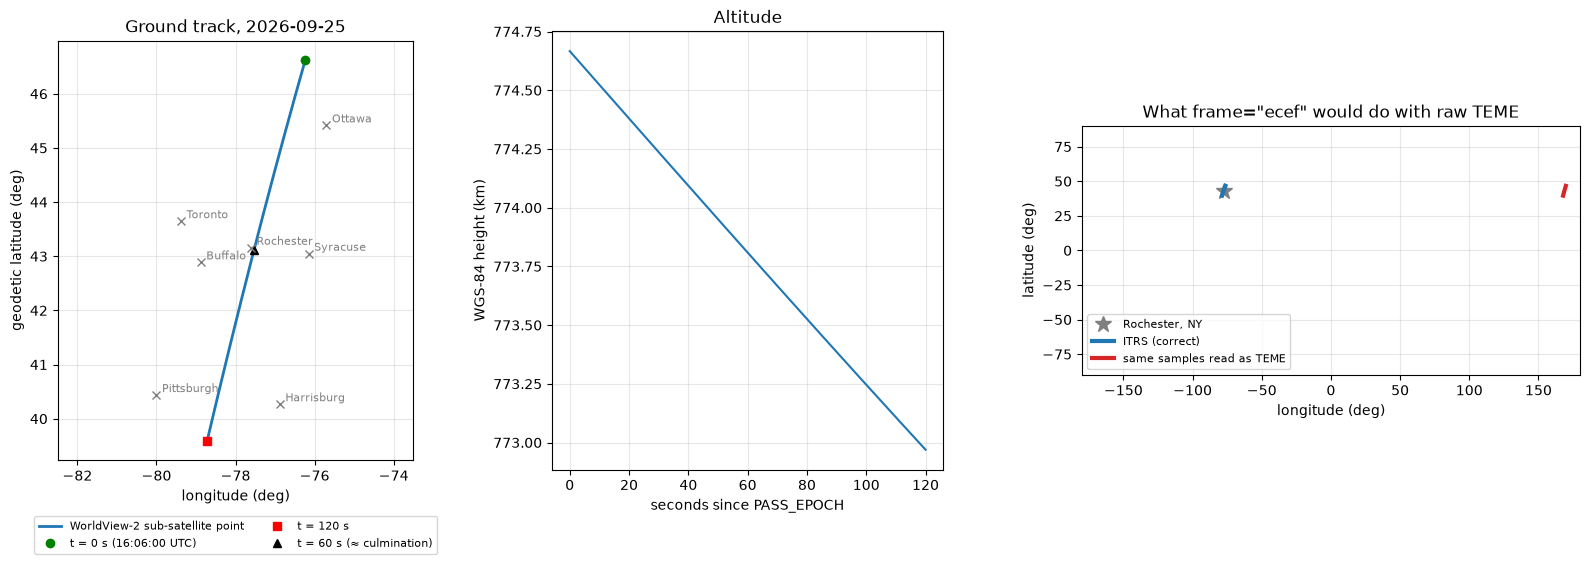

own vs skyfield geodetic: max |dlat| 7.6e-09 deg, |dlon| 4.3e-14 deg, |dh| 4.3e-09 m
lat  46.631 -> 39.585 deg,  lon -76.233 -> -78.720 deg,  heading 194.4 deg
height 772.97 .. 774.67 km
closest approach to Rochester, NY: 7.14 km at t = 59.54 s
ground distance covered ~ 809 km
TEME-as-ECEF would put the t = 60 s sub-point at 43.1, 168.7 — 8,382 km away


In [9]:
import matplotlib.pyplot as plt

WGS84_A = 6378137.0                    # semi-major axis, m
WGS84_F = 1 / 298.257223563
WGS84_E2 = WGS84_F * (2 - WGS84_F)     # first eccentricity squared

def ecef_to_geodetic(xyz, iters=6):
    """ECEF (m) -> (lat deg, lon deg, height m) on WGS-84, by fixed-point iteration on latitude."""
    x, y, z = np.asarray(xyz, dtype=float).T
    lon = np.arctan2(y, x)
    p = np.hypot(x, y)
    lat = np.arctan2(z, p * (1 - WGS84_E2))                       # initial guess
    for _ in range(iters):
        n = WGS84_A / np.sqrt(1 - WGS84_E2 * np.sin(lat) ** 2)   # prime-vertical radius
        h = p / np.cos(lat) - n
        lat = np.arctan2(z, p * (1 - WGS84_E2 * n / (n + h)))
    n = WGS84_A / np.sqrt(1 - WGS84_E2 * np.sin(lat) ** 2)
    h = p / np.cos(lat) - n
    return np.degrees(lat), np.degrees(lon), h

def ground_km(lat1, lon1, lat2, lon2):
    """Great-circle distance (km, spherical Earth) — adequate for a sanity check."""
    p1, p2, dl = np.radians(lat1), np.radians(lat2), np.radians(lon2 - lon1)
    return 6371.0 * np.arccos(np.clip(np.sin(p1) * np.sin(p2) + np.cos(p1) * np.cos(p2) * np.cos(dl), -1, 1))

lat, lon, alt = ecef_to_geodetic(pos)
sp = wgs84.subpoint_of(geo)
d_lat = np.abs(lat - sp.latitude.degrees).max()
d_lon = np.abs(lon - sp.longitude.degrees).max()
d_h = np.abs(alt - wgs84.height_of(geo).m).max()
lat_bad, lon_bad, _ = ecef_to_geodetic(pos_teme)            # the trap, for the plot only

tgt_lat, tgt_lon = TARGET.latitude.degrees, TARGET.longitude.degrees
miss = ground_km(lat, lon, tgt_lat, tgt_lon)
mid = len(t) // 2

cities = {"Toronto": (43.65, -79.38), "Rochester": (43.16, -77.61), "Buffalo": (42.89, -78.88),
          "Syracuse": (43.05, -76.15), "Pittsburgh": (40.44, -80.00), "Harrisburg": (40.27, -76.88),
          "Ottawa": (45.42, -75.70)}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1.1, 1.4]})
ax1.plot(lon, lat, lw=2, label="WorldView-2 sub-satellite point")
ax1.plot(lon[0], lat[0], "go", label=f"t = 0 s ({PASS_EPOCH:%H:%M:%S} UTC)")
ax1.plot(lon[-1], lat[-1], "rs", label=f"t = {t[-1]:.0f} s")
ax1.plot(lon[mid], lat[mid], "k^", label=f"t = {t[mid]:.0f} s (≈ culmination)")
for cname, (clat, clon) in cities.items():
    ax1.plot(clon, clat, "x", color="gray")
    ax1.annotate(cname, (clon, clat), xytext=(4, 2), textcoords="offset points", fontsize=8, color="gray")
ax1.set(xlabel="longitude (deg)", ylabel="geodetic latitude (deg)",
        title=f"Ground track, {PASS_EPOCH:%Y-%m-%d}", xlim=(-82.5, -73.5))
ax1.set_aspect(1 / np.cos(np.radians(lat.mean())))   # locally equal-distance axes
ax1.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2); ax1.grid(alpha=0.3)

ax2.plot(t, alt / 1e3)
ax2.set(xlabel="seconds since PASS_EPOCH", ylabel="WGS-84 height (km)", title="Altitude")
ax2.grid(alpha=0.3)

ax3.plot(tgt_lon, tgt_lat, "*", color="gray", ms=12, label=TARGET_NAME)
ax3.plot(lon, lat, lw=3, label="ITRS (correct)")
ax3.plot(lon_bad, lat_bad, lw=3, color="C3", label="same samples read as TEME")
ax3.set(xlim=(-180, 180), ylim=(-90, 90), xlabel="longitude (deg)", ylabel="latitude (deg)",
        title="What frame=\"ecef\" would do with raw TEME")
ax3.set_aspect(1); ax3.grid(alpha=0.3); ax3.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

heading = np.degrees(np.arctan2(np.diff(lon)[mid] * np.cos(np.radians(lat[mid])), np.diff(lat)[mid])) % 360
print(f"own vs skyfield geodetic: max |dlat| {d_lat:.1e} deg, |dlon| {d_lon:.1e} deg, |dh| {d_h:.1e} m")
print(f"lat  {lat[0]:.3f} -> {lat[-1]:.3f} deg,  lon {lon[0]:.3f} -> {lon[-1]:.3f} deg,  heading {heading:.1f} deg")
print(f"height {alt.min() / 1e3:.2f} .. {alt.max() / 1e3:.2f} km")
print(f"closest approach to {TARGET_NAME}: {miss.min():.2f} km at t = {t[miss.argmin()]:.2f} s")
print(f"ground distance covered ~ {ground_km(lat[0], lon[0], lat[-1], lon[-1]):.0f} km")
print(f"TEME-as-ECEF would put the t = {t[mid]:.0f} s sub-point at {lat_bad[mid]:.1f}, {lon_bad[mid]:.1f} "
      f"— {ground_km(lat[mid], lon[mid], lat_bad[mid], lon_bad[mid]):,.0f} km away")

assert d_lat < 1e-6 and d_lon < 1e-6 and d_h < 1e-2
assert 750e3 < alt.min() and alt.max() < 790e3
assert lat[-1] < lat[0], "expected a descending pass"
assert miss.min() < 20.0

## Orientation: nadir-pointing LookAt

dirfm has no quaternion engine (Stage 0), and a TLE carries no attitude anyway. We use DIRSIG's
own idiom for a satellite that stays pointed straight down. A **LookAt** orientation engine
aims the sensor at a target produced by a nested location engine. With a **Fixed** location
engine at **ECEF (0, 0, 0)**, the target is the centre of the Earth, so the boresight always
points along the local geocentric vertical. This is the pattern the DIRSIG FlexMotion manual's
"Landsat Orbit" example uses, and it is `StkImport1`'s own `stare.motion`. dirfm has every
piece: `LookAtOrientationEngine`, `FixedLocationEngine` and `frames.ECEFFrame`.

> **Substitution:** this is a **nadir-pointing idealisation**, not a measured attitude. What
> is real is the trajectory. There is no off-nadir slew, roll or yaw steering.

### The "up" vector, checked for *this* pass

LookAt fixes where the boresight points. It still needs an `up` vector to fix the sensor's roll
around that axis. `stare.motion` uses `<up type="velocity" frame="ecef">`, which makes the
image's up direction the direction of flight. dirfm cannot write that (Stage 0, Q2c): it
always emits a constant `<up frame="scene" vector="…"/>`, where the scene frame is
East–North–Up at the scene origin. Stage 2 puts that origin at the target.

A fixed vector must satisfy two things over the whole pass, and neither carries over
automatically from one pass geometry to another:

1. **It must stay well away from the boresight.** If `up` and the line of sight are nearly
   parallel, the roll is undefined. dirfm's default `up = [0, 0, 1]` (scene Up) fails this
   badly for a satellite looking straight down. As the satellite moves along the track, the
   nadir boresight, seen in the target's ENU frame, tilts by the geocentric angle between the
   satellite and the target, a few degrees here. So we compute the angle over every sample
   rather than assume 90°.
2. **It should be close to what `<up type="velocity">` would have given**, so that the image
   orientation matches DIRSIG's own idiom. We compare both vectors after projecting them onto
   the plane perpendicular to the boresight, since that projection is what actually sets the
   roll.

The earlier STK version of this notebook used scene North, `[0, 1, 0]`, and described it as
close to velocity-up. For a **descending** pass that is wrong: the satellite is flying roughly
south, so North is nearly *opposite* velocity-up and the image would come out about 165°
rotated. The cell tests North alongside the replacement, a **fixed along-track vector**: the
horizontal (E, N) direction of the ITRS velocity at culmination, taken from the propagation
rather than chosen by hand.

In [10]:
vel = np.gradient(pos, t, axis=0)                        # ECEF velocity, m/s (finite difference)

phi, lam = np.radians(tgt_lat), np.radians(tgt_lon)      # scene origin = pass target (Stage 2)
E = np.array([-np.sin(lam), np.cos(lam), 0.0])
N = np.array([-np.sin(phi) * np.cos(lam), -np.sin(phi) * np.sin(lam), np.cos(phi)])
U = np.cross(E, N)
ECEF_TO_ENU = np.vstack([E, N, U])                       # rows: scene E, N, U in ECEF

bore = (-pos / np.linalg.norm(pos, axis=1, keepdims=True)) @ ECEF_TO_ENU.T   # nadir LOS, scene ENU
vel_enu = vel @ ECEF_TO_ENU.T

along = vel_enu[mid].copy()
along[2] = 0.0
along /= np.linalg.norm(along)
UP_VECTOR = [round(float(v), 6) for v in along]

def perp_unit(u, b):
    """Component of u perpendicular to unit vector(s) b, normalised."""
    p = u - np.sum(u * b, axis=-1, keepdims=True) * b
    return p / np.linalg.norm(p, axis=-1, keepdims=True)

vel_up = perp_unit(vel_enu / np.linalg.norm(vel_enu, axis=1, keepdims=True), bore)
print(f"{'up vector (scene ENU)':34s} {'angle to boresight':>22s} {'roll vs velocity-up':>22s}")
for label, up in {"dirfm default  [0, 0, 1]  (Up)": [0, 0, 1],
                  "scene North    [0, 1, 0]": [0, 1, 0],
                  f"along-track    {UP_VECTOR}": UP_VECTOR}.items():
    up = np.array(up, float) / np.linalg.norm(up)
    ang = np.degrees(np.arccos(np.clip(bore @ up, -1, 1)))
    roll = np.degrees(np.arccos(np.clip(np.sum(perp_unit(np.broadcast_to(up, bore.shape), bore) * vel_up, axis=1), -1, 1)))
    print(f"{label:34s}   {ang.min():7.2f} .. {ang.max():6.2f}°    {roll.min():7.2f} .. {roll.max():6.2f}°")

up = np.array(UP_VECTOR) / np.linalg.norm(UP_VECTOR)
ang = np.degrees(np.arccos(bore @ up))
roll = np.degrees(np.arccos(np.clip(np.sum(perp_unit(np.broadcast_to(up, bore.shape), bore) * vel_up, axis=1), -1, 1)))
assert np.all(np.abs(ang - 90) < 10), "up vector too close to the boresight somewhere in the pass"
assert roll.max() < 2.0, "fixed up drifts too far from velocity-up over the pass"

up vector (scene ENU)                  angle to boresight    roll vs velocity-up
dirfm default  [0, 0, 1]  (Up)        176.17 .. 179.89°       1.95 .. 178.23°
scene North    [0, 1, 0]               86.27 ..  93.31°     165.25 .. 165.94°
along-track    [-0.248526, -0.968625, 0.0]     86.56 ..  93.83°       0.00 ..   0.35°


**Result.** For this pass the fixed along-track vector stays close to perpendicular to the
boresight over all 120 s, and it tracks true velocity-up to a fraction of a degree. Scene North
would also have been geometrically *valid*, but it would have rolled the image by about 165°
relative to `stare.motion`. The default `[0, 0, 1]` is nearly anti-parallel to the line of
sight and unusable. `UP_VECTOR` depends on the pass geometry: if `TARGET` or the TLE changes,
this cell recomputes it and re-runs both asserts.

## Location: explicit ECEF waypoints

We thin the 0.01-s track to **1-second waypoints** (121 points) and check what that costs.
Between two waypoints the true path curves away from the straight chord by about
$v^2 \Delta t^2 / (8 r)$, which is roughly 1 m for $v \approx 7.5$ km/s, $\Delta t = 1$ s and
$r \approx 7{,}140$ km. We measure it directly by linearly interpolating the 1-s waypoints back
onto the dense grid. That is a worst-case bound, since DIRSIG may interpolate at higher order.

**Times are relative to `PASS_EPOCH`.** Stage 2's `TASKS` reference datetime must be
`PASS_EPOCH`, printed above. Otherwise the whole track shifts in time without any error.

In [11]:
from dirfm import frames

WAYPOINT_DT = 1.0                                   # seconds between waypoints
step = int(round(WAYPOINT_DT / DENSE_DT))
idx = np.arange(0, len(t), step)
assert idx[-1] == len(t) - 1, "thinning must keep the final sample"
t_wp, pos_wp = t[idx], pos[idx]

interp = np.column_stack([np.interp(t, t_wp, pos_wp[:, k]) for k in range(3)])
chord_err = np.linalg.norm(interp - pos, axis=1)
print(f"{len(t_wp)} waypoints at {WAYPOINT_DT:g}-s spacing; "
      f"max linear-interpolation error vs 0.01-s track = {chord_err.max():.2f} m")

location = fm.WaypointsLocationEngine(frame="ecef")    # pos is ITRS (ECEF), verified above
for ti, p in zip(t_wp, pos_wp):
    location.add_point(round(float(ti), 6), [float(v) for v in p])

orientation = fm.LookAtOrientationEngine(
    fm.FixedLocationEngine(frames.ECEFFrame(0.0, 0.0, 0.0)),   # look at the Earth's centre
    up=UP_VECTOR,                                              # fixed along-track (see above)
)
orbit_motion = fm.FlexMotion(location, orientation)

121 waypoints at 1-s spacing; max linear-interpolation error vs 0.01-s track = 1.00 m


### Inspect the generated `<motion>` XML

`FlexMotion.write()` can write into an in-memory XML element as well as to a file, so we can
see exactly what DIRSIG will receive before any scene exists. There is `source="internal"`,
`frame="ecef"` with ITRS numbers inline, and a nadir LookAt with the fixed along-track `up`.
Only the first and last few waypoint rows are shown. As a last guard, the cell parses the
waypoint rows back out of the XML and checks that they are the ITRS positions, not the TEME
ones.

In [12]:
import lxml.etree as et

root = et.Element("platform")
orbit_motion.write(root)
xml_lines = et.tostring(root, pretty_print=True).decode().splitlines()
data_rows = [i for i, ln in enumerate(xml_lines) if ln[:1].isdigit()]
shown = xml_lines[: data_rows[3]] + [f"  ... {len(data_rows) - 6} more waypoint rows ..."] + xml_lines[data_rows[-3]:]
print("\n".join(shown))

written = np.array([[float(v) for v in xml_lines[i].split(",")] for i in data_rows])
assert len(written) == len(t_wp) and root.find(".//locationengine/data").get("frame") == "ecef"
assert np.allclose(written[:, 1:], pos_wp) and not np.allclose(written[:, 1:], pos_teme[idx])

<platform>
  <motion type="flexible">
    <locationengine type="waypoints">
      <data source="internal" datetime="relative" frame="ecef" delimiter="," loop="false"><![CDATA[
0.0,1170755.9268760912,-4778197.300935387,5176852.843393383
1.0,1170114.8614645842,-4783802.956238926,5171828.623854123
2.0,1169471.707274699,-4789403.3191193435,5166798.741687114
  ... 115 more waypoint rows ...
118.0,1081107.0792962105,-5401467.223593806,4546417.352872214
119.0,1080230.5007035797,-5406405.773122899,4540764.442522231
120.0,1079352.0278879418,-5411338.3169178,4535106.558513205
]]></data>
    </locationengine>
    <orientationengine type="lookat">
      <locationengine type="fixed">
        <location frame="ecef">
          <x>0.0</x>
          <y>0.0</y>
          <z>0.0</z>
        </location>
      </locationengine>
      <up frame="scene" vector="-0.248526,-0.968625,0.0"/>
    </orientationengine>
  </motion>
</platform>


### Stage 1 summary

* **Source.** The current Celestrak TLE for catalog 35946. The catalog confirms it is
  WorldView-2 (2009-055A) and both checksums are valid. It is cached in
  `outputs/_orbit_data/` so re-runs are reproducible.
* **Pass.** Chosen by the stated rule: the highest daylight culmination over Rochester, NY
  within 7 days of the TLE epoch. The window is 120 s centred on culmination, starting at
  `PASS_EPOCH`.
* **Frame.** SGP4's TEME output was converted to ITRS (ECEF) by skyfield, not by hand. That
  conversion was checked against an independent GMST for axis, sign and rate. The notebook
  also measured the cost of getting this wrong: about 8,000–9,000 km of position error, with
  no warning from anything.
* **Sanity checks.** The altitude and ground track match WorldView-2 and the chosen pass. Our
  own geodetic conversion agrees with skyfield's.
* **FlexMotion pair.** Location is `WaypointsLocationEngine(frame="ecef")` with 121 one-second
  ITRS waypoints. Orientation is a nadir `LookAt` at ECEF (0, 0, 0) with a fixed along-track
  `up`. That `up` was verified for this pass to stay near-perpendicular to the boresight and to
  track velocity-up closely. It stands in for the `up type="velocity"` mode that dirfm lacks.
* **Handed to Stage 2.** The scene origin must be `TARGET` (the up-vector check assumed it),
  and the `TASKS` reference datetime must be `PASS_EPOCH`.